In [1]:
#Carregar as bibliotecas

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os
import cv2
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.math import confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
tf.keras.utils.set_random_seed(5)
tf.config.experimental.enable_op_determinism()

I0000 00:00:1786216344.555941    9727 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


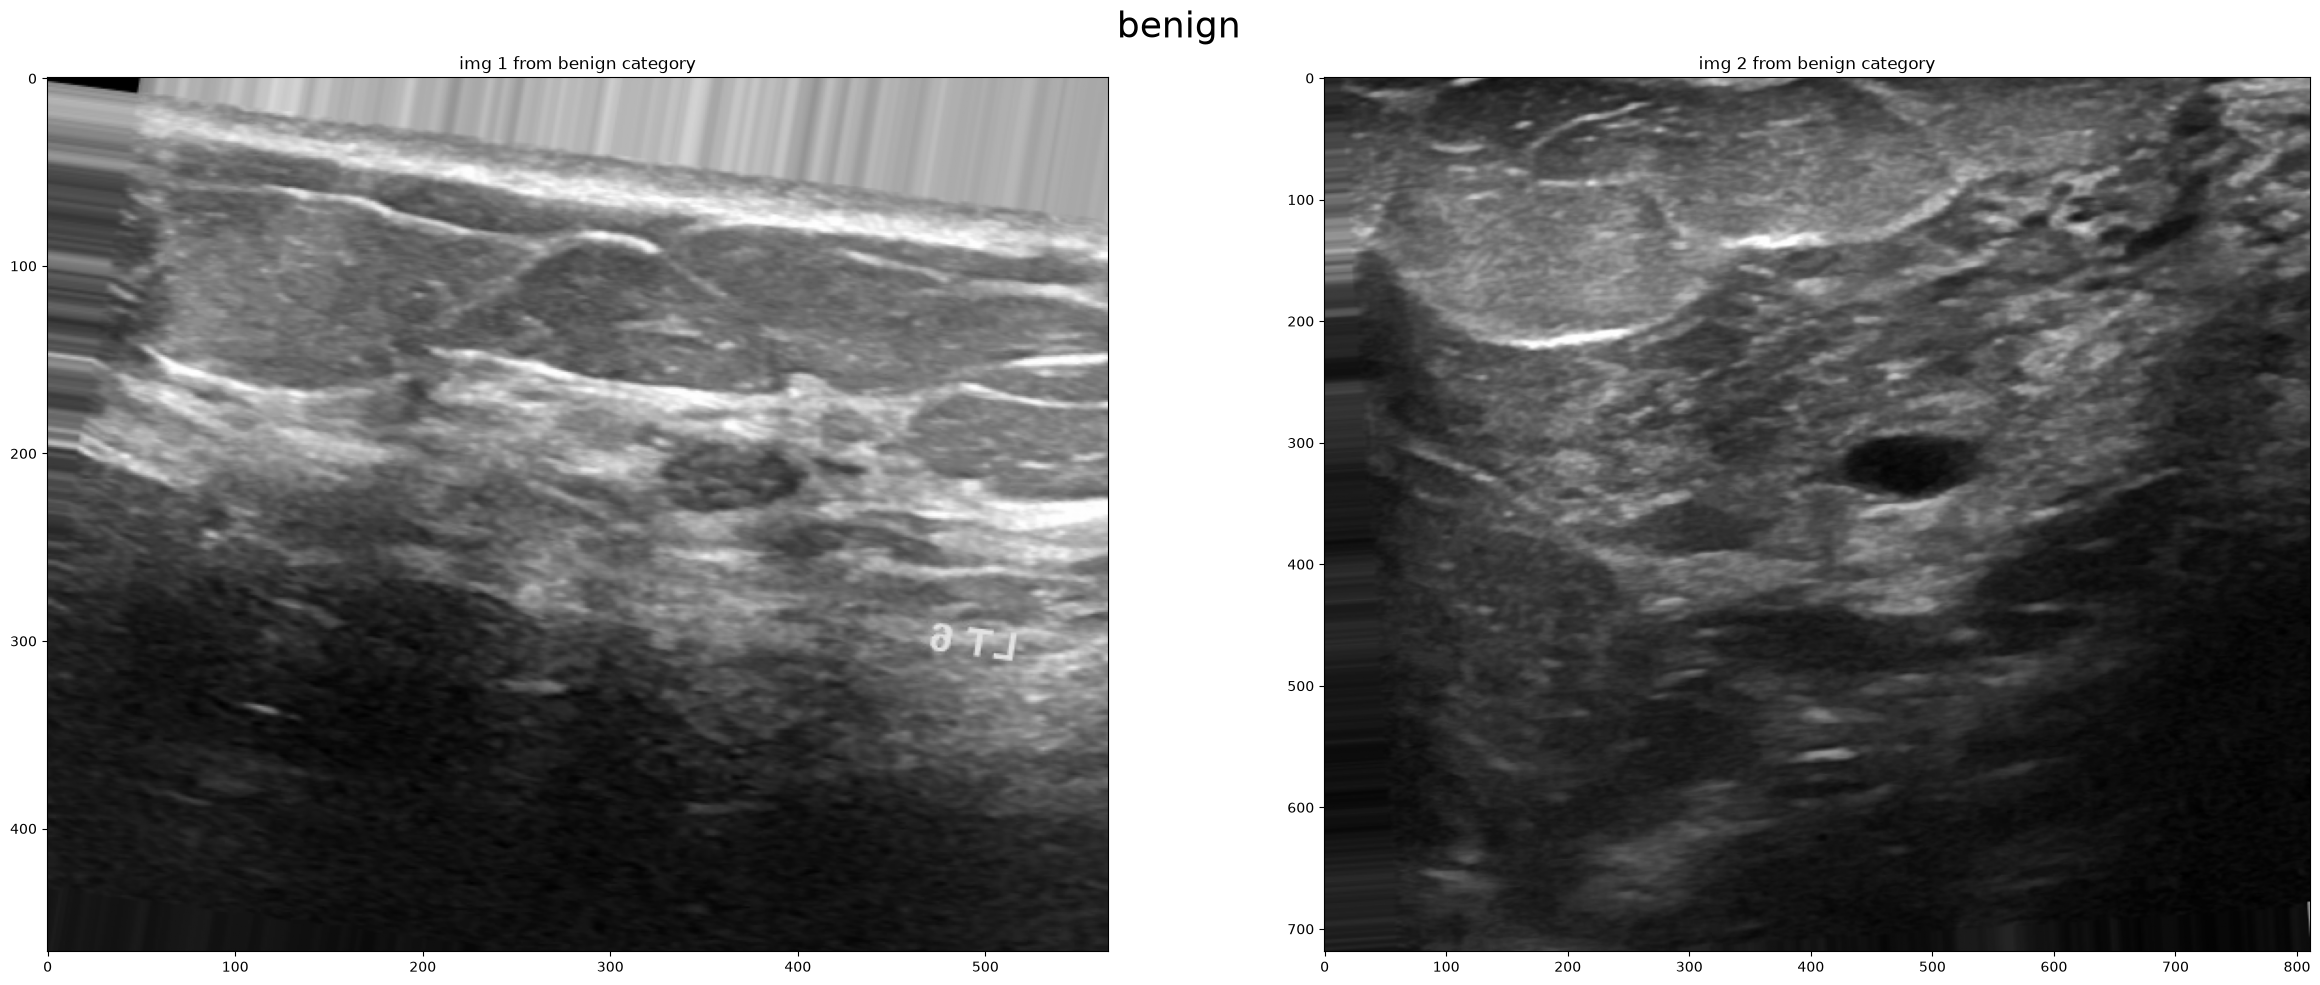

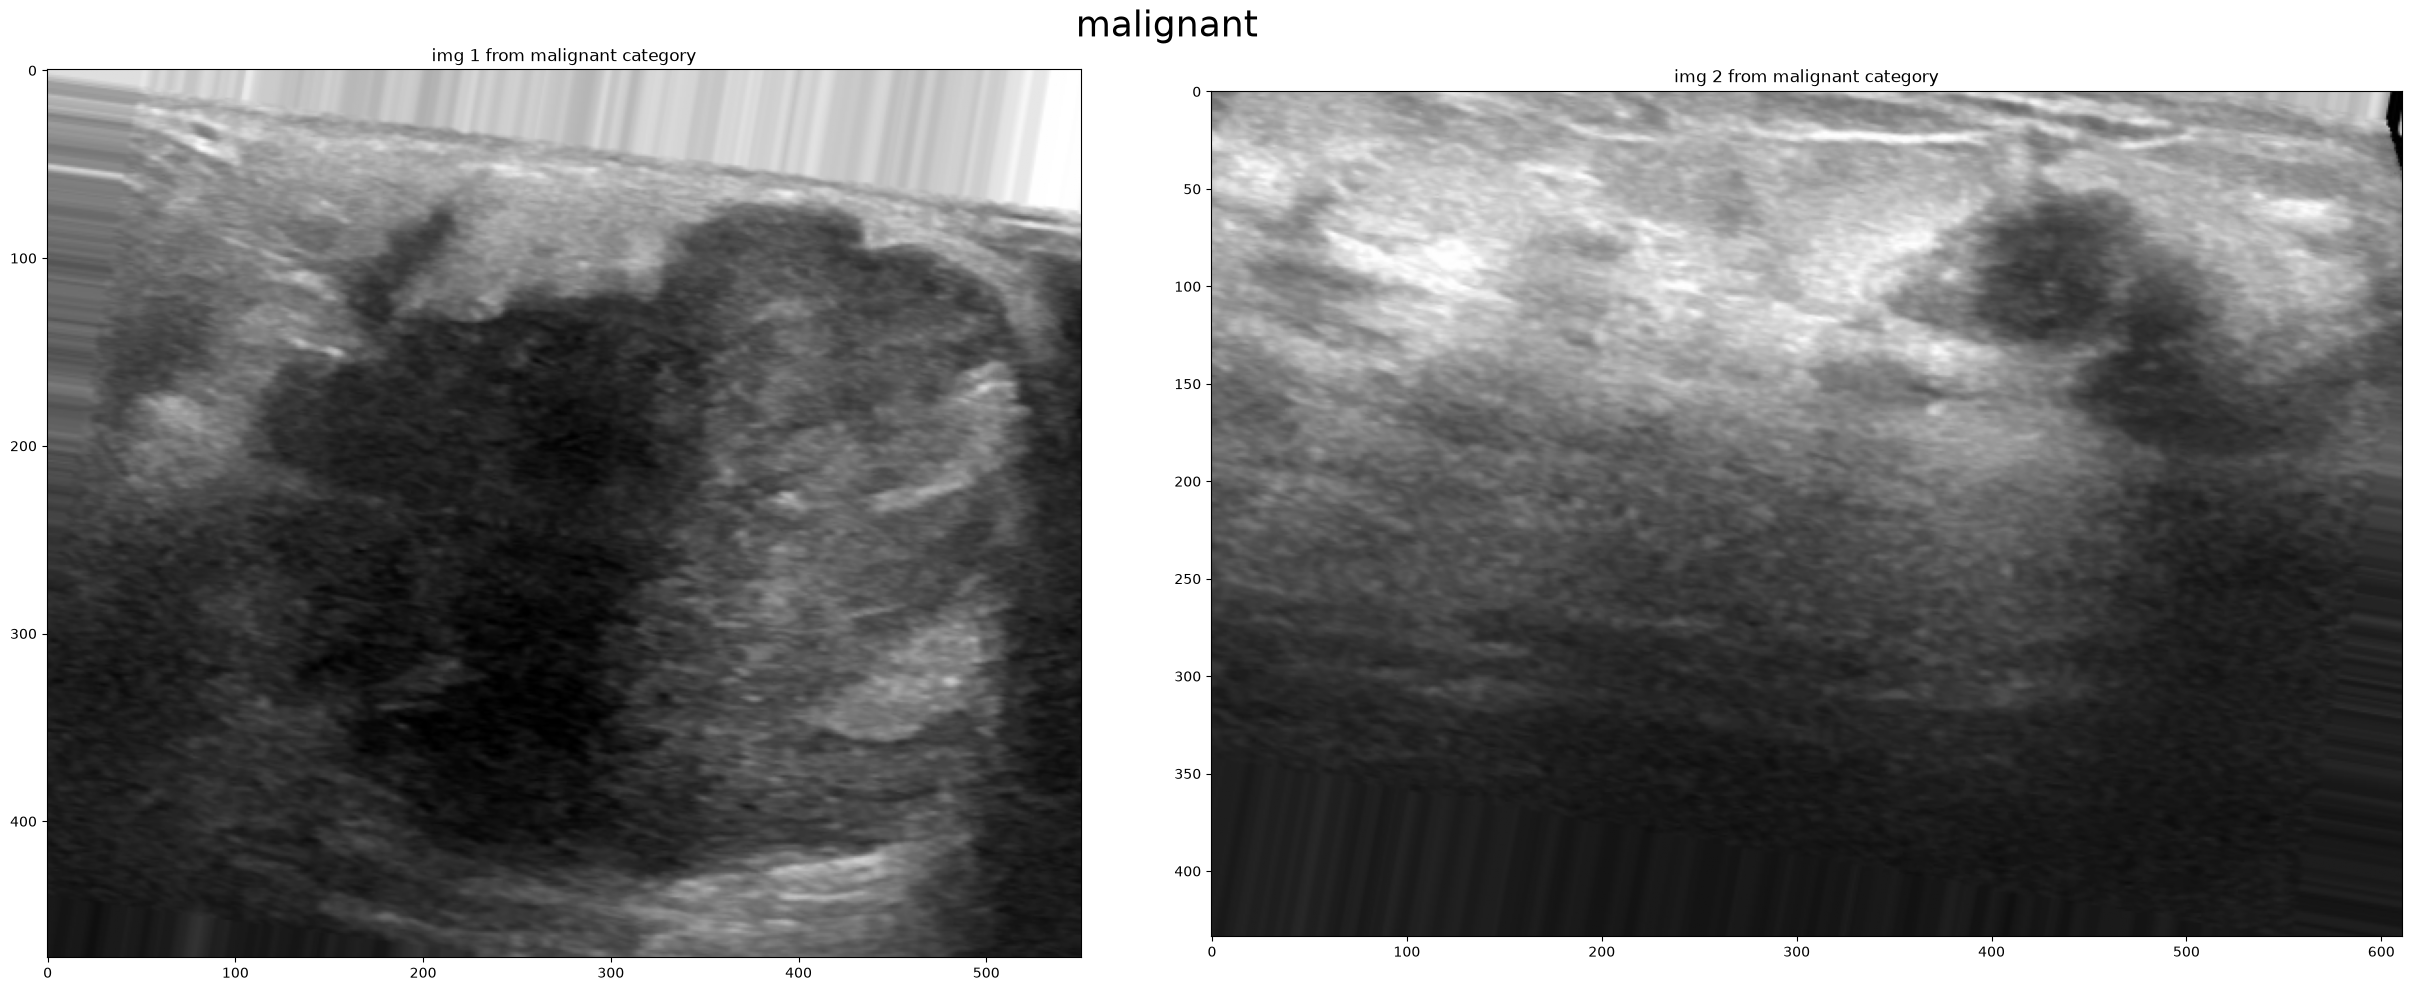

In [2]:
#Dados sobre conjunto de imagens de ultrassom de mama que contém 2 Classes [benigno, maligno] Exibindo 2 imagens de cada classe

import os
import cv2
import matplotlib.pyplot as plt

# Novo caminho da base de dados
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/train_augmented'
files_names = ['benign', 'malignant']  # Apenas as duas classes desejadas

for file in files_names:
    path = os.path.join(folder_name, file)
    x = 0
    fig, axes = plt.subplots(1, 2, figsize=(25, 10))  
    
    for img in os.listdir(path):
        if not img.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue  # Ignora arquivos que não são imagens

        img_path = os.path.join(path, img)
        if not os.path.isfile(img_path):
            continue  # Garante que é um arquivo

        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            continue  # Ignora arquivos corrompidos ou inválidos

        axes[x].imshow(img_array, cmap='gray')
        axes[x].set_title(f"img {x+1} from {file} category")
        x += 1
        if x == 2: 
            break

    plt.suptitle(file, fontsize=26)
    plt.tight_layout()
    plt.show()

In [3]:
# Carregando dados

import os
import cv2
from tqdm import tqdm

# Caminho para a pasta contendo as imagens de treino
folder_name = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/train_augmented'

# Classes que queremos carregar
files_names = ['benign', 'malignant']

# Tamanho das imagens
img_sz = 224

# Lista para armazenar os dados de treino
training_data = []

def create_training_data():
    for file in files_names:
        path = os.path.join(folder_name, file)
        class_num = files_names.index(file)  # 0 para benign, 1 para malignant
        print(file, class_num)

        for img in tqdm(os.listdir(path)):
            img_path = os.path.join(path, img)

            # Filtros para evitar imagens indesejadas
            if not img.lower().endswith('.png'):
                continue
            if not os.path.isfile(img_path):
                continue

            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img_array is None:
                continue  # evita erro se a imagem estiver corrompida

            new_array = cv2.resize(img_array, (img_sz, img_sz))
            training_data.append([new_array, class_num])

# Executar a função
create_training_data()


benign 0


100%|█████████████████████████████████████| 1302/1302 [00:03<00:00, 371.04it/s]


malignant 1


100%|███████████████████████████████████████| 744/744 [00:01<00:00, 396.94it/s]


In [4]:
# Os dados têm imagens benignas e malignas. Embaralhando e exibindo as primeiras 20 classes

import random

# Embaralha os dados de treino
random.shuffle(training_data)

# Exibe as primeiras 30 amostras com suas classes
for i in range(30):
    print(f"Sample {i+1}:")
    print("Class number:", training_data[i][1], "\n")


Sample 1:
Class number: 1 

Sample 2:
Class number: 1 

Sample 3:
Class number: 0 

Sample 4:
Class number: 1 

Sample 5:
Class number: 0 

Sample 6:
Class number: 0 

Sample 7:
Class number: 0 

Sample 8:
Class number: 1 

Sample 9:
Class number: 1 

Sample 10:
Class number: 0 

Sample 11:
Class number: 0 

Sample 12:
Class number: 0 

Sample 13:
Class number: 1 

Sample 14:
Class number: 0 

Sample 15:
Class number: 0 

Sample 16:
Class number: 0 

Sample 17:
Class number: 1 

Sample 18:
Class number: 0 

Sample 19:
Class number: 1 

Sample 20:
Class number: 0 

Sample 21:
Class number: 0 

Sample 22:
Class number: 0 

Sample 23:
Class number: 0 

Sample 24:
Class number: 0 

Sample 25:
Class number: 0 

Sample 26:
Class number: 0 

Sample 27:
Class number: 0 

Sample 28:
Class number: 0 

Sample 29:
Class number: 0 

Sample 30:
Class number: 0 



In [5]:
import numpy as np

X = []
y = []

# Percorre as amostras de treinamento
for feature, label in training_data:
    X.append(feature)
    y.append(label)

# Converte as listas em arrays numpy
X = np.array(X)
y = np.array(y)

# Adiciona a dimensão para o canal (escala de cinza)
X = np.expand_dims(X, axis=-1)  # Adiciona a dimensão do canal de cor (1 para grayscale)

# Verificando a forma de X e y
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (2046, 224, 224, 1)
y shape: (2046,)


In [6]:
from sklearn.model_selection import train_test_split

# Divisão dos dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar as formas dos conjuntos de dados
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(1636, 224, 224, 1)
(1636,)
(410, 224, 224, 1)
(410,)


In [7]:
# Valores únicos em y (Classes)

print(np.unique(y_train))

print(np.unique(y_test))

[0 1]
[0 1]


In [8]:
# Normalização para 0-1
X_train = X_train/255
X_test = X_test/255

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras import layers, models

def coord_attention(x, reduction=32):
    input_channels = x.shape[-1]

    # ----- Pooling -----
    h_pool = layers.Lambda(lambda z: tf.reduce_mean(z, axis=2, keepdims=True))(x)
    w_pool = layers.Lambda(lambda z: tf.reduce_mean(z, axis=1, keepdims=True))(x)

    w_pool = layers.Lambda(lambda z: tf.transpose(z, perm=[0, 2, 1, 3]))(w_pool)

    # ----- Concat -----
    y = layers.Concatenate(axis=1)([h_pool, w_pool])

    # ----- Bottleneck -----
    reduced_channels = max(8, input_channels // reduction)

    y = layers.Conv2D(reduced_channels, kernel_size=1,
                      padding='same',
                      use_bias=False,
                      kernel_initializer='he_normal')(y)

    y = layers.BatchNormalization()(y)
    y = layers.Activation('relu')(y)

    # ----- Split -----
    h, w = layers.Lambda(lambda z: tf.split(z, num_or_size_splits=2, axis=1))(y)

    w = layers.Lambda(lambda z: tf.transpose(z, perm=[0, 2, 1, 3]))(w)

    # ----- Attention maps -----
    h_att = layers.Conv2D(input_channels, kernel_size=1,
                          padding='same',
                          activation='sigmoid',
                          use_bias=False,
                          kernel_initializer='he_normal')(h)

    w_att = layers.Conv2D(input_channels, kernel_size=1,
                          padding='same',
                          activation='sigmoid',
                          use_bias=False,
                          kernel_initializer='he_normal')(w)

    # ----- Apply -----
    out = layers.Multiply()([x, h_att])
    out = layers.Multiply()([out, w_att])

    return out

# Agora o modelo com CoordAttention
import tensorflow as tf
from tensorflow.keras import layers, models

img_sz = 224

inputs = layers.Input(shape=(img_sz, img_sz, 1))

x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = coord_attention(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = coord_attention(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = coord_attention(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(256, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
x = coord_attention(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(64, activation='relu')(x)

outputs = layers.Dense(2, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

W0000 00:00:1786216352.950493    9727 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1786216352.954842    9727 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1786216353.050985    9727 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9364 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:08:00.0, compute capability: 12.0a


In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1, 224,    │          0 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 1,    │          0 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 224, 1,    │          0 │ lambda_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 448, 1,    │          0 │ lambda[0][0],     │
│ (Concatenate)       │ 32)               │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 448, 1, 8) │        256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 448, 1, 8) │         32 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 448, 1, 8) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ [(None, 224, 1,   │          0 │ activation[0][0]  │
│                     │ 8), (None, 224,   │            │                   │
│                     │ 1, 8)]            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 1,    │        256 │ lambda_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 1, 224, 8) │          0 │ lambda_3[0][1]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ conv2d[0][0],     │
│                     │ 32)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 1, 224,    │        256 │ lambda_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 224, 224,  │          0 │ multiply[0][0],   │
│ (Multiply)          │ 32)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ multiply_1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                 

 Total params: 442,690 (1.69 MB)

 Trainable params: 441,666 (1.68 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss',  # ou 'val_accuracy'
                               patience=10,          # número de épocas sem melhora antes de parar
                               restore_best_weights=True)  # restaura os melhores pesos

history = model.fit(X_train, y_train,
                    epochs=50,
                    validation_split=0.2,
                    batch_size=8,
                    callbacks=[early_stopping])

Epoch 1/50


E0000 00:00:1786216354.586523    9727 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1786216358.549977    9848 cuda_dnn.cc:461] Loaded cuDNN version 92400


164/164 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6934 - loss: 0.6017 - val_accuracy: 0.3140 - val_loss: 0.7219
Epoch 2/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7370 - loss: 0.5588 - val_accuracy: 0.3140 - val_loss: 0.9274
Epoch 3/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7622 - loss: 0.5158 - val_accuracy: 0.3140 - val_loss: 1.4752
Epoch 4/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7699 - loss: 0.4978 - val_accuracy: 0.3841 - val_loss: 1.2020
Epoch 5/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7882 - loss: 0.4767 - val_accuracy: 0.7409 - val_loss: 0.5261
Epoch 6/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8050 - loss: 0.4396 - val_accuracy: 0.8140 - val_loss: 0.4299
Epoch 7/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8119 - loss: 0.4339 - val_accuracy: 0.7744 - val_loss: 0.4707
Epoch 8/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8349 - loss: 0.3845 - val_accuracy: 0.79

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Accuarcy of the model is : {accuracy*100:.2f} %")

E0000 00:00:1786216462.481100    9727 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8707 - loss: 0.2759
Accuarcy of the model is : 87.07 %


In [13]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Fazer a predição com o modelo
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar a matriz de confusão
conf_mat = confusion_matrix(y_test, y_pred_classes)



13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


In [14]:
y_pred = [np.argmax(i) for i in y_pred]
print(y_pred)

[np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)

In [15]:
# Supondo que você tenha as classes "Benign" e "Malignant"
comparison_df = pd.DataFrame({ 'Actual': y_test,'Predicted': y_pred})

print(comparison_df[:20])

    Actual  Predicted
0        1          1
1        0          0
2        1          1
3        1          1
4        1          1
5        0          0
6        0          0
7        0          0
8        1          1
9        0          0
10       0          0
11       1          1
12       1          0
13       1          1
14       0          0
15       1          1
16       0          0
17       0          1
18       1          1
19       1          1


In [16]:
from sklearn.metrics import classification_report
import numpy as np

# Obter as predições do modelo no conjunto de teste completo
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Relatório de classificação
print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
              precision    recall  f1-score   support

      benign       0.86      0.94      0.90       249
   malignant       0.89      0.77      0.82       161

    accuracy                           0.87       410
   macro avg       0.87      0.85      0.86       410
weighted avg       0.87      0.87      0.87       410



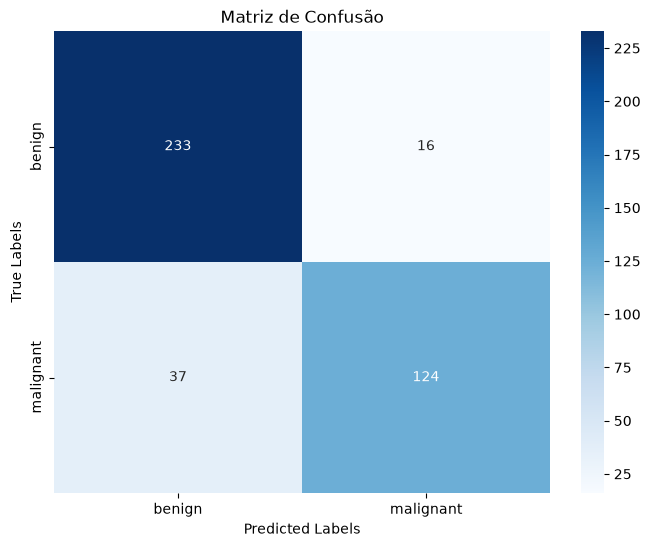

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mostrar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['benign', 'malignant'],
            yticklabels=['benign', 'malignant'])
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title('Matriz de Confusão')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


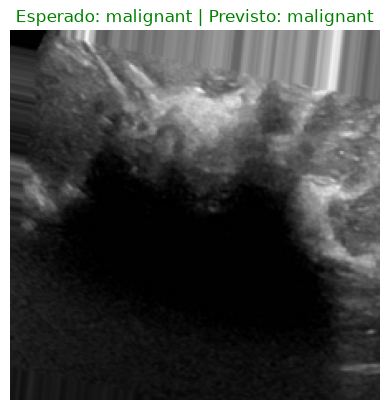

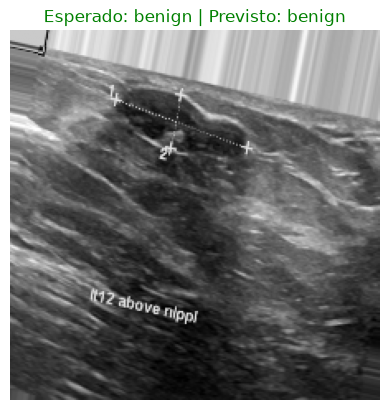

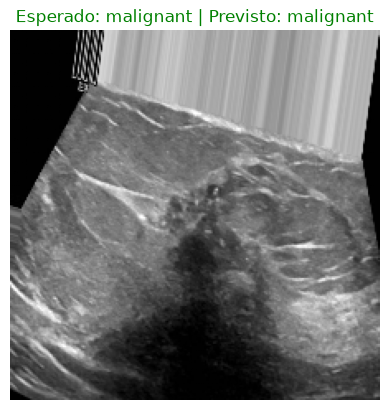

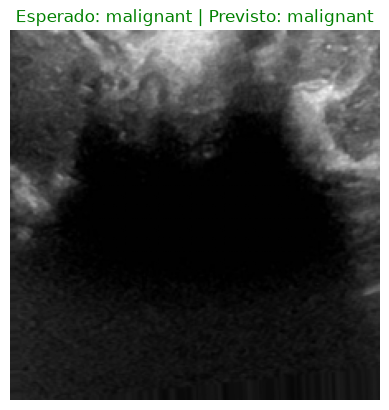

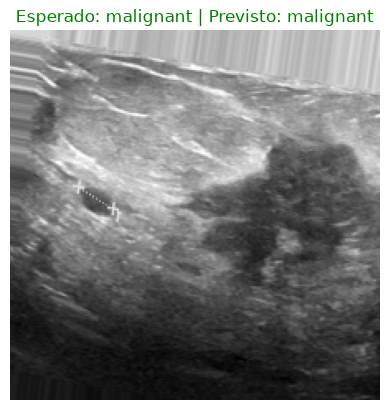

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Dicionário com as duas classes
class_names = {0: 'benign', 1: 'malignant'}

# Número de amostras que você quer prever
num_samples = 5

# Predição
predictions = model.predict(X_test[:num_samples])
predicted_classes = np.argmax(predictions, axis=1)

# Mostrar as imagens com a classe real e a prevista
for i in range(num_samples):
    plt.imshow(X_test[i].squeeze(), cmap='gray')  # .squeeze() remove canal extra se tiver
    esperado = class_names[y_test[i]]
    previsto = class_names[predicted_classes[i]]
    cor_titulo = 'green' if esperado == previsto else 'red'
    
    plt.title(f"Esperado: {esperado} | Previsto: {previsto}", color=cor_titulo)
    plt.axis('off')
    plt.show()


In [19]:
import os
import cv2
import numpy as np

# Caminhos das pastas
benign_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/validation/benign'
malignant_path = '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/BUSI_CLEAN/validation/malignant'

# Parâmetros
img_sz = 224
class_names = {0: 'benign', 1: 'malignant'}

def load_images_from_folder(folder_path, label):
    images = []
    labels = []

    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            img = cv2.resize(img, (img_sz, img_sz))
            img = img.astype('float32') / 255.0
            img = np.expand_dims(img, axis=-1)  # (224, 224, 1)

            images.append(img)
            labels.append(label)

    return images, labels


In [20]:
benign_imgs, benign_labels = load_images_from_folder(benign_path, 0)
malignant_imgs, malignant_labels = load_images_from_folder(malignant_path, 1)

X_val = np.array(benign_imgs + malignant_imgs)
y_val = np.array(benign_labels + malignant_labels)

print(f'Total de imagens: {X_val.shape[0]}')
print(f'Benign: {np.sum(y_val == 0)} | Malignant: {np.sum(y_val == 1)}')


Total de imagens: 73
Benign: 47 | Malignant: 26


In [21]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Accuracy on test set: {accuracy*100:.2f}%")

Accuracy on test set: 84.93%


In [22]:
from sklearn.metrics import confusion_matrix

# Predição
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Matriz de confusão
conf_mat = confusion_matrix(y_val, y_pred_classes)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [23]:
from sklearn.metrics import classification_report
import numpy as np

# 🔹 Predições no conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 🔹 Checagem de consistência (ESSENCIAL)
print(len(y_val), len(y_pred_classes))  # Deve ser: 900 900

# 🔹 Relatório de classificação
print(classification_report(
    y_val,
    y_pred_classes,
    target_names=['benign', 'malignant']
))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
73 73
              precision    recall  f1-score   support

      benign       0.85      0.94      0.89        47
   malignant       0.86      0.69      0.77        26

    accuracy                           0.85        73
   macro avg       0.85      0.81      0.83        73
weighted avg       0.85      0.85      0.85        73



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
73 73


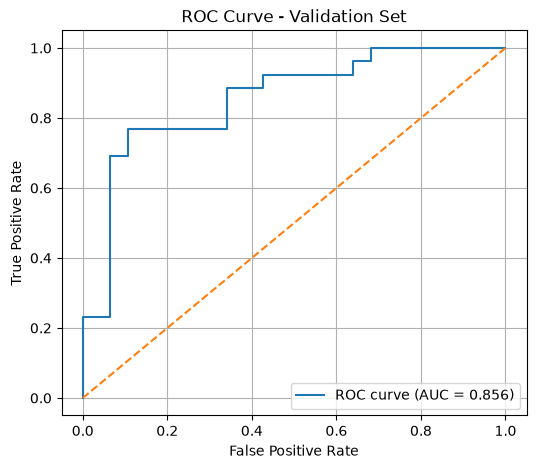

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 🔹 1. Recalcular predições com o conjunto correto (900 imagens)
y_pred_probs = model.predict(X_val)

# 🔹 2. Pegar probabilidade da classe positiva (malignant = 1)
y_scores = y_pred_probs[:, 1]

# 🔹 3. Conferência (boa prática)
print(len(y_val), len(y_scores))  # Deve ser: 900 900

# 🔹 4. Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)

# 🔹 5. Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

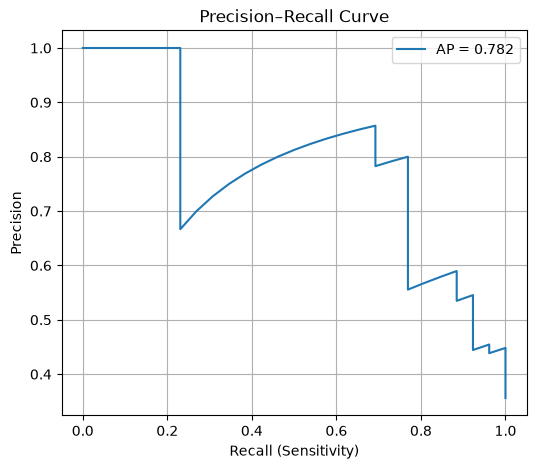

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_val, y_scores)
ap_score = average_precision_score(y_val, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


In [26]:
print(len(y_val), len(y_pred_classes))

73 73


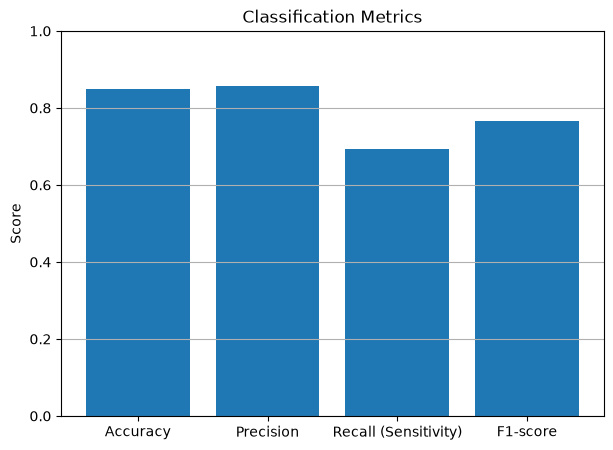

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_val, y_pred_classes)
precision = precision_score(y_val, y_pred_classes)
recall = recall_score(y_val, y_pred_classes)   # Sensibilidade (malignant)
f1 = f1_score(y_val, y_pred_classes)

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'F1-score': f1
}

plt.figure(figsize=(7, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Classification Metrics')
plt.grid(axis='y')
plt.show()


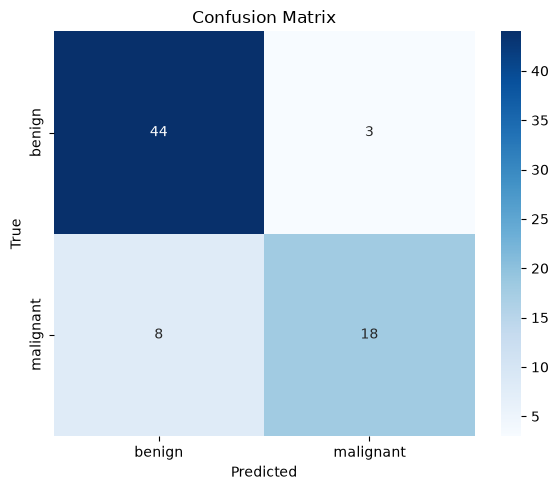

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['benign', 'malignant'],
    yticklabels=['benign', 'malignant']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


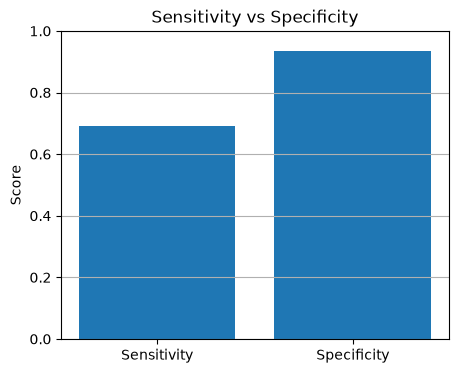

In [29]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

plt.figure(figsize=(5, 4))
plt.bar(['Sensitivity', 'Specificity'], [sensitivity, specificity])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Sensitivity vs Specificity')
plt.grid(axis='y')
plt.show()


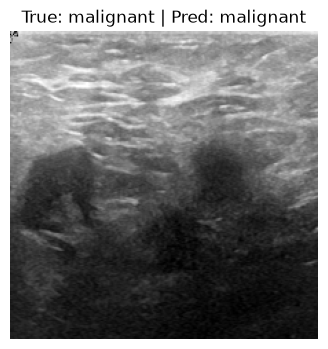

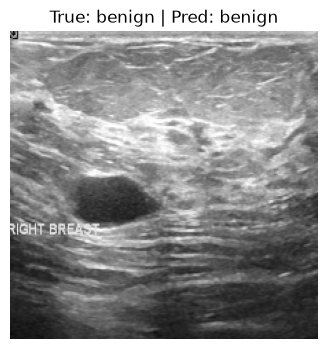

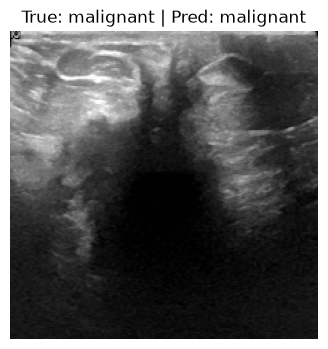

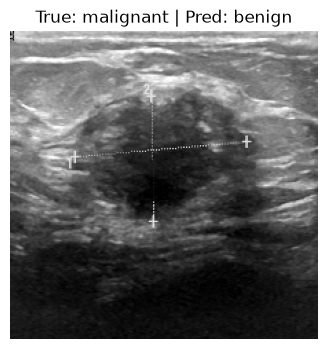

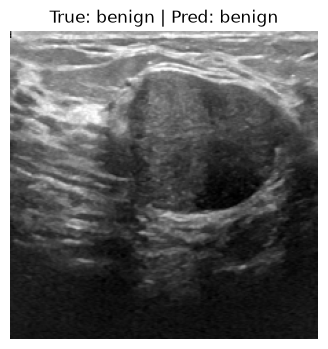

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Número de imagens para visualização
num_images = 5

# (Opcional) Para reprodutibilidade
np.random.seed(42)

for _ in range(num_images):
    # Índice aleatório
    random_idx = np.random.randint(0, len(X_val))

    # Imagem
    img = X_val[random_idx].squeeze()

    # Rótulos
    true_label = class_names[y_val[random_idx]]
    pred_label = class_names[y_pred_classes[random_idx]]

    # Plot
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.axis('off')
    plt.show()



RESULTADO DA CLASSIFICAÇÃO
Arquivo: benign (186).png
Classe real: benign
Classe prevista: benign
Confiança: 0.9971
Probabilidades: [0.9971187  0.00288127]
Resultado: CORRETO


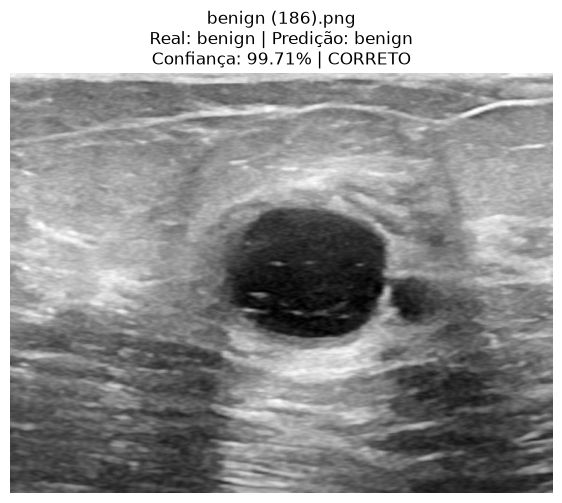

In [31]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CAMINHO DO CONJUNTO DE TESTE
# ============================================================

test_dir = (
    '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/'
    'BUSI_CLEAN/test'
)


# ============================================================
# PARÂMETROS
# ============================================================

img_sz = 224

class_names = {
    0: 'benign',
    1: 'malignant'
}


# ============================================================
# SELECIONAR UMA IMAGEM ALEATÓRIA
# ENTRE AS DUAS CLASSES
# ============================================================

image_list = []

for class_name in ['benign', 'malignant']:

    class_dir = os.path.join(
        test_dir,
        class_name
    )

    for filename in os.listdir(class_dir):

        if filename.lower().endswith(
            ('.png', '.jpg', '.jpeg')
        ):

            image_list.append(
                (
                    os.path.join(
                        class_dir,
                        filename
                    ),
                    class_name,
                    filename
                )
            )


if len(image_list) == 0:
    raise ValueError(
        "Nenhuma imagem encontrada no conjunto de teste."
    )


# Seleciona uma imagem aleatória
img_path, real_class, filename = random.choice(
    image_list
)


# ============================================================
# FUNÇÃO DE PRÉ-PROCESSAMENTO
# ============================================================

def preprocess_image(img_path):

    # Carregar como grayscale
    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError(
            f"Erro ao carregar a imagem: {img_path}"
        )

    # Redimensionar
    img = cv2.resize(
        img,
        (img_sz, img_sz)
    )

    # Converter para float32
    img = img.astype('float32')

    # Normalizar para intervalo [0,1]
    img = img / 255.0

    # (224,224) -> (224,224,1)
    img = np.expand_dims(
        img,
        axis=-1
    )

    # (224,224,1) -> (1,224,224,1)
    img = np.expand_dims(
        img,
        axis=0
    )

    return img


# ============================================================
# PRÉ-PROCESSAR IMAGEM
# ============================================================

img_input = preprocess_image(
    img_path
)


# ============================================================
# FAZER PREDIÇÃO
# ============================================================

pred_probs = model.predict(
    img_input,
    verbose=0
)

pred_class = np.argmax(
    pred_probs,
    axis=1
)[0]

confidence = np.max(
    pred_probs
)

predicted_class = class_names[
    pred_class
]


# ============================================================
# VERIFICAR SE A PREDIÇÃO ESTÁ CORRETA
# ============================================================

correct = (
    predicted_class == real_class
)


# ============================================================
# MOSTRAR RESULTADO
# ============================================================

print("\n====================================")
print("RESULTADO DA CLASSIFICAÇÃO")
print("====================================")

print(f"Arquivo: {filename}")

print(f"Classe real: {real_class}")

print(
    f"Classe prevista: {predicted_class}"
)

print(
    f"Confiança: {confidence:.4f}"
)

print(
    f"Probabilidades: {pred_probs[0]}"
)


if correct:

    print("Resultado: CORRETO")

else:

    print("Resultado: INCORRETO")


# ============================================================
# EXIBIR IMAGEM
# ============================================================

img_display = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)


plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    img_display,
    cmap='gray'
)


status = (
    "CORRETO"
    if correct
    else "INCORRETO"
)


plt.title(
    f"{filename}\n"
    f"Real: {real_class} | "
    f"Predição: {predicted_class}\n"
    f"Confiança: {confidence:.2%} | "
    f"{status}"
)


plt.axis('off')

plt.show()

Colunas do CSV:
['ID', 'Pathology', 'kFold', 'valid_1', 'valid_2', 'valid_3', 'valid_4', 'valid_5']

Imagem selecionada:
bus_0100-l.png
ID procurado no CSV:
bus_0100-l
Classe real:
benign

RESULTADO DA CLASSIFICAÇÃO
Arquivo: bus_0100-l.png
Classe real: benign
Classe prevista: benign
Confiança: 0.9508
Probabilidades: [0.9508287 0.0491713]
Resultado: CORRETO


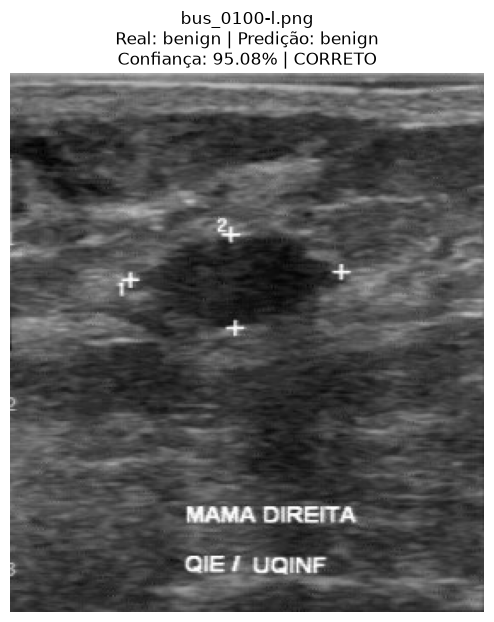

In [32]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CAMINHOS
# ============================================================

images_dir = (
    '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/'
    'BUSBRA/Images'
)

csv_path = (
    '/home/pc/Projeto/Ultrasound Breast Images for Breast Cancer/'
    'BUSBRA/5-fold-cv.csv'
)


# ============================================================
# CARREGAR O CSV
# ============================================================

df = pd.read_csv(csv_path)

# Remover possíveis espaços extras dos nomes das colunas
df.columns = df.columns.str.strip()

print("Colunas do CSV:")
print(df.columns.tolist())


# ============================================================
# SELECIONAR UMA IMAGEM ALEATÓRIA
# ============================================================

image_files = [
    file for file in os.listdir(images_dir)
    if file.lower().endswith(('.png', '.jpg', '.jpeg'))
]

if len(image_files) == 0:
    raise ValueError("Nenhuma imagem encontrada na pasta.")


selected_image = random.choice(image_files)

img_path = os.path.join(
    images_dir,
    selected_image
)


# ============================================================
# OBTER O ID DA IMAGEM
#
# Exemplo:
# bus_0930-r.png -> bus_0930-r
# ============================================================

image_id = os.path.splitext(selected_image)[0]


# ============================================================
# PROCURAR A CLASSE REAL NO CSV
# ============================================================

# Garantir que ID seja string e sem espaços extras
df['ID'] = df['ID'].astype(str).str.strip()

row = df[df['ID'] == image_id]


if row.empty:

    real_class = "não encontrada"

    print(
        f"\nAVISO: o ID {image_id} "
        "não foi encontrado no arquivo CSV."
    )

else:

    real_class = (
        row.iloc[0]['Pathology']
    )

    real_class = str(
        real_class
    ).strip().lower()


print("\nImagem selecionada:")
print(selected_image)

print("ID procurado no CSV:")
print(image_id)

print("Classe real:")
print(real_class)


# ============================================================
# PARÂMETROS DO MODELO
# ============================================================

img_sz = 224

class_names = {
    0: 'benign',
    1: 'malignant'
}


# ============================================================
# PRÉ-PROCESSAMENTO
# ============================================================

def preprocess_image(img_path):

    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError(
            f"Erro ao carregar a imagem: {img_path}"
        )

    # Redimensionar
    img = cv2.resize(
        img,
        (img_sz, img_sz)
    )

    # Converter para float
    img = img.astype('float32')

    # Normalização
    img = img / 255.0

    # (224,224) -> (224,224,1)
    img = np.expand_dims(
        img,
        axis=-1
    )

    # (224,224,1) -> (1,224,224,1)
    img = np.expand_dims(
        img,
        axis=0
    )

    return img


# ============================================================
# PRÉ-PROCESSAR
# ============================================================

img_input = preprocess_image(
    img_path
)


# ============================================================
# PREDIÇÃO
# ============================================================

pred_probs = model.predict(
    img_input,
    verbose=0
)

pred_class = np.argmax(
    pred_probs,
    axis=1
)[0]

confidence = np.max(
    pred_probs
)

predicted_class = class_names[
    pred_class
]


# ============================================================
# VERIFICAR SE ACERTOU
# ============================================================

if real_class != "não encontrada":

    correct = (
        predicted_class.lower()
        ==
        real_class.lower()
    )

else:

    correct = False


# ============================================================
# MOSTRAR RESULTADO
# ============================================================

print("\n====================================")
print("RESULTADO DA CLASSIFICAÇÃO")
print("====================================")

print(
    f"Arquivo: {selected_image}"
)

print(
    f"Classe real: {real_class}"
)

print(
    f"Classe prevista: {predicted_class}"
)

print(
    f"Confiança: {confidence:.4f}"
)

print(
    f"Probabilidades: {pred_probs[0]}"
)


if real_class != "não encontrada":

    if correct:

        print("Resultado: CORRETO")

    else:

        print("Resultado: INCORRETO")


# ============================================================
# EXIBIR IMAGEM
# ============================================================

img_display = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)


plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    img_display,
    cmap='gray'
)


if real_class != "não encontrada":

    status = (
        "CORRETO"
        if correct
        else "INCORRETO"
    )

    plt.title(
        f"{selected_image}\n"
        f"Real: {real_class} | "
        f"Predição: {predicted_class}\n"
        f"Confiança: {confidence:.2%} | "
        f"{status}"
    )

else:

    plt.title(
        f"{selected_image}\n"
        f"Predição: {predicted_class} "
        f"({confidence:.2%})\n"
        f"Classe real não encontrada"
    )


plt.axis('off')

plt.show()

In [33]:
# ============================================================
# ANÁLISE DE COMPLEXIDADE COMPUTACIONAL DO MODELO
# ============================================================

import tensorflow as tf
import numpy as np
import time

from tensorflow.python.framework.convert_to_constants import (
    convert_variables_to_constants_v2
)


# ------------------------------------------------------------
# 1. NÚMERO DE PARÂMETROS
# ------------------------------------------------------------

total_params = model.count_params()

trainable_params = np.sum([
    np.prod(v.shape) for v in model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape) for v in model.non_trainable_weights
])

print("\n" + "=" * 60)
print("COMPLEXIDADE DO MODELO")
print("=" * 60)

print(f"TensorFlow:               {tf.__version__}")
print(f"Parâmetros totais:        {total_params:,}")
print(f"Parâmetros treináveis:    {trainable_params:,}")
print(f"Parâmetros não treináveis:{non_trainable_params:,}")


# ------------------------------------------------------------
# 2. FLOPs
# ------------------------------------------------------------

def get_flops(model):
    """
    Calcula aproximadamente o número de FLOPs
    para uma passagem forward do modelo com batch_size = 1.
    """

    # Obtém o formato de entrada do modelo sem o batch
    input_shape = model.input_shape[1:]

    # Cria uma função concreta do modelo
    concrete_function = tf.function(
        lambda inputs: model(inputs, training=False)
    )

    concrete_function = concrete_function.get_concrete_function(
        tf.TensorSpec(
            [1] + list(input_shape),
            dtype=tf.float32
        )
    )

    # Converte as variáveis do modelo em constantes
    frozen_func = convert_variables_to_constants_v2(
        concrete_function
    )

    # Obtém o grafo congelado
    graph = frozen_func.graph

    # Configuração do profiler para contar operações de ponto flutuante
    with graph.as_default():

        options = (
            tf.compat.v1.profiler.ProfileOptionBuilder
            .float_operation()
        )

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            options=options
        )

    if flops is None:
        return 0

    return flops.total_float_ops


try:

    flops = get_flops(model)

    print("\n" + "=" * 60)
    print("FLOPs")
    print("=" * 60)

    print(f"FLOPs:  {flops:,}")
    print(f"MFLOPs: {flops / 1e6:.4f}")
    print(f"GFLOPs: {flops / 1e9:.4f}")

except Exception as e:

    print("\nNão foi possível calcular FLOPs automaticamente.")
    print("Erro:", e)


# ------------------------------------------------------------
# 3. TEMPO DE INFERÊNCIA
# ------------------------------------------------------------

# Número de imagens usadas no benchmark
num_images = min(100, len(X_test))

X_benchmark = X_test[:num_images]


# ------------------------------------------------------------
# WARM-UP
# ------------------------------------------------------------
# As primeiras execuções podem incluir inicialização
# da GPU, compilação de kernels e alocação de memória.
# Por isso, elas não devem entrar no cálculo final.

for _ in range(10):
    _ = model(X_benchmark[:1], training=False)


# ------------------------------------------------------------
# MEDIÇÃO INDIVIDUAL
# ------------------------------------------------------------

inference_times = []

for i in range(num_images):

    img = X_benchmark[i:i+1]

    start = time.perf_counter()

    _ = model(img, training=False)

    end = time.perf_counter()

    inference_times.append(end - start)


inference_times = np.array(inference_times)

mean_time = np.mean(inference_times)
std_time = np.std(inference_times)

mean_ms = mean_time * 1000
std_ms = std_time * 1000

fps = 1 / mean_time


print("\n" + "=" * 60)
print("TEMPO DE INFERÊNCIA")
print("=" * 60)

print(f"Imagens avaliadas: {num_images}")

print(
    f"Tempo médio por imagem: "
    f"{mean_ms:.3f} ± {std_ms:.3f} ms"
)

print(f"FPS aproximado: {fps:.2f}")

print("=" * 60)


COMPLEXIDADE DO MODELO
TensorFlow:               2.21.0
Parâmetros totais:        442,690
Parâmetros treináveis:    441,666
Parâmetros não treináveis:1,024
Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


I0000 00:00:1786216466.852459    9727 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1786216466.852534    9727 single_machine.cc:376] Starting new session
W0000 00:00:1786216466.856818    9727 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1786216466.858997    9727 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9364 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:08:00.0, compute capability: 12.0a



FLOPs
FLOPs:  1,442,235,980
MFLOPs: 1442.2360
GFLOPs: 1.4422

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: